# Домашнее задание 3

## Визуализация данных о пассажирах «Титаника»


# 1. Загрузка датасета

Считаем файл `train.csv` и посмотрим первые строки.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv("train.csv")

df.head()

AttributeError: 'RcParams' object has no attribute '_get'

# 2. Распределение признаков

Построим распределения `Survived`, `Pclass`, `Age`, `Sex` и `Parch`.

Для категориальных признаков используем столбчатые диаграммы, для возраста — гистограмму.

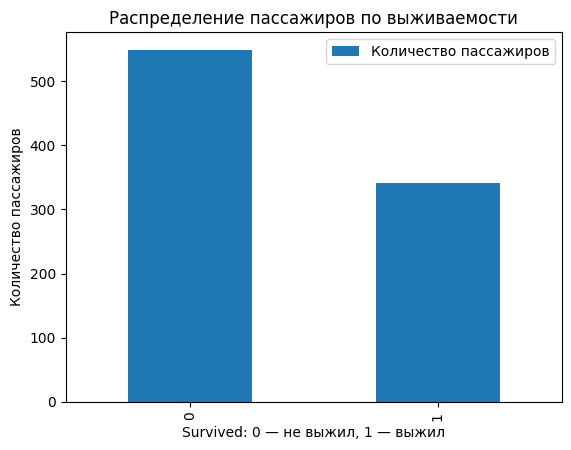

In [2]:
survived_counts = df["Survived"].value_counts().sort_index()

survived_counts.plot(kind="bar")
plt.title("Распределение пассажиров по выживаемости")
plt.xlabel("Survived: 0 — не выжил, 1 — выжил")
plt.ylabel("Количество пассажиров")
plt.legend(["Количество пассажиров"])
plt.show()

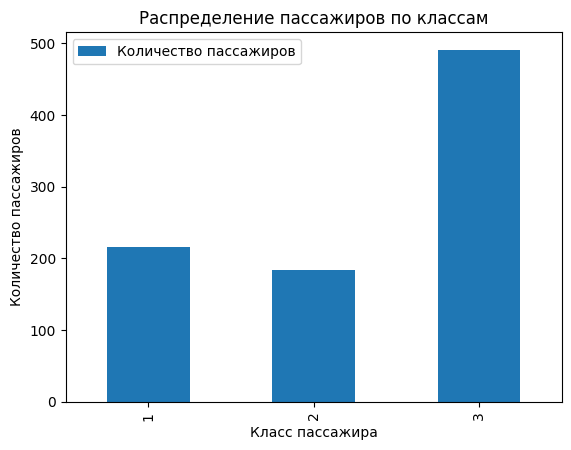

In [3]:
class_counts = df["Pclass"].value_counts().sort_index()

class_counts.plot(kind="bar")
plt.title("Распределение пассажиров по классам")
plt.xlabel("Класс пассажира")
plt.ylabel("Количество пассажиров")
plt.legend(["Количество пассажиров"])
plt.show()

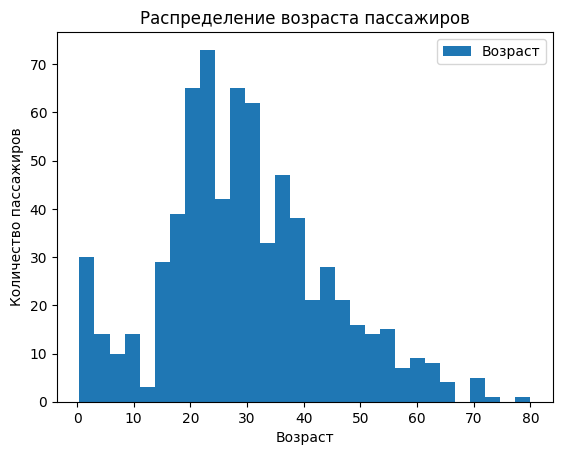

In [4]:
df["Age"].dropna().plot(kind="hist", bins=30)
plt.title("Распределение возраста пассажиров")
plt.xlabel("Возраст")
plt.ylabel("Количество пассажиров")
plt.legend(["Возраст"])
plt.show()

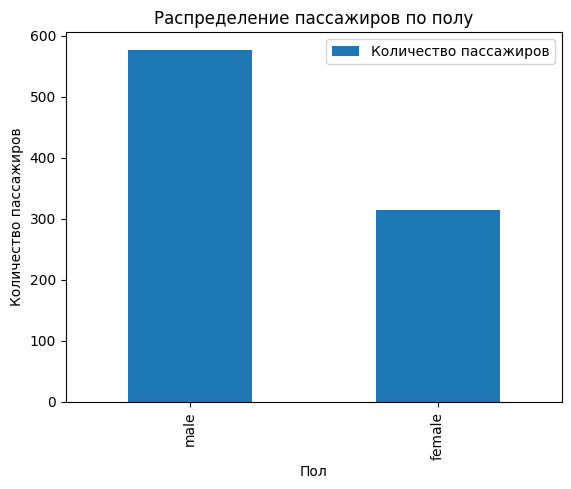

In [5]:
sex_counts = df["Sex"].value_counts()

sex_counts.plot(kind="bar")
plt.title("Распределение пассажиров по полу")
plt.xlabel("Пол")
plt.ylabel("Количество пассажиров")
plt.legend(["Количество пассажиров"])
plt.show()

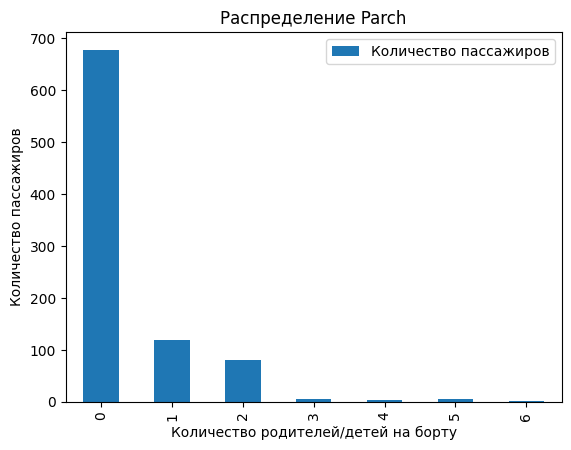

In [6]:
parch_counts = df["Parch"].value_counts().sort_index()

parch_counts.plot(kind="bar")
plt.title("Распределение Parch")
plt.xlabel("Количество родителей/детей на борту")
plt.ylabel("Количество пассажиров")
plt.legend(["Количество пассажиров"])
plt.show()

# 3. Boxplot для `Age`

Boxplot позволяет увидеть медиану, основную часть распределения и возможные выбросы.

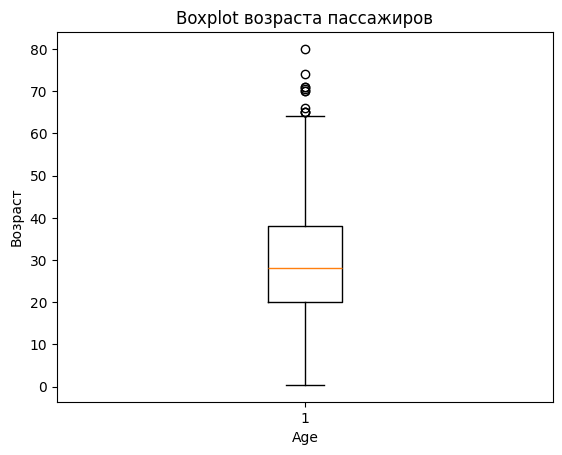

In [7]:
plt.boxplot(df["Age"].dropna())
plt.title("Boxplot возраста пассажиров")
plt.xlabel("Age")
plt.ylabel("Возраст")
plt.show()

## Интерпретация boxplot

Медианный возраст пассажиров составляет примерно 28 лет.

Основная часть пассажиров находится примерно в диапазоне от 20 до 38 лет. На графике также видны отдельные значения в области старших возрастов. Они находятся далеко от основной части распределения и поэтому отображаются как выбросы.

Можно сделать вывод, что на корабле было заметно больше молодых людей и людей среднего возраста, чем пожилых пассажиров.

# 4. Pie chart для `Survived`

Покажем долю выживших и погибших пассажиров в процентах.

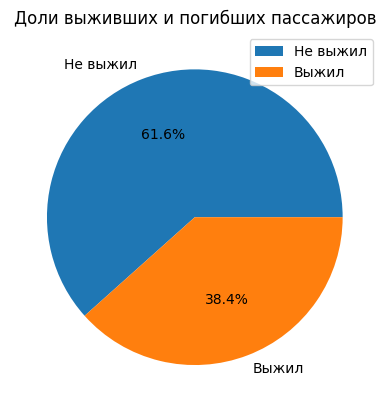

In [8]:
survived_counts = df["Survived"].value_counts().sort_index()

plt.pie(
    survived_counts,
    labels=["Не выжил", "Выжил"],
    autopct="%1.1f%%"
)
plt.title("Доли выживших и погибших пассажиров")
plt.legend(["Не выжил", "Выжил"])
plt.show()

# 5. Pie chart для `Pclass`

Покажем долю пассажиров каждого класса в процентах.

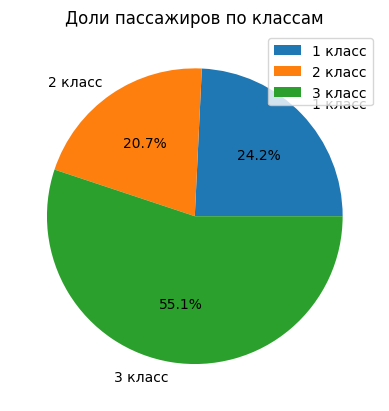

In [9]:
class_counts = df["Pclass"].value_counts().sort_index()

plt.pie(
    class_counts,
    labels=["1 класс", "2 класс", "3 класс"],
    autopct="%1.1f%%"
)
plt.title("Доли пассажиров по классам")
plt.legend(["1 класс", "2 класс", "3 класс"])
plt.show()

# 6. Pairplot для числовых переменных

Построим матрицу попарных графиков для всех числовых признаков.

`scatter_matrix` показывает те же попарные зависимости, что и график типа `pairplot`: на пересечении признаков отображаются диаграммы рассеяния, а на диагонали — распределения отдельных признаков.

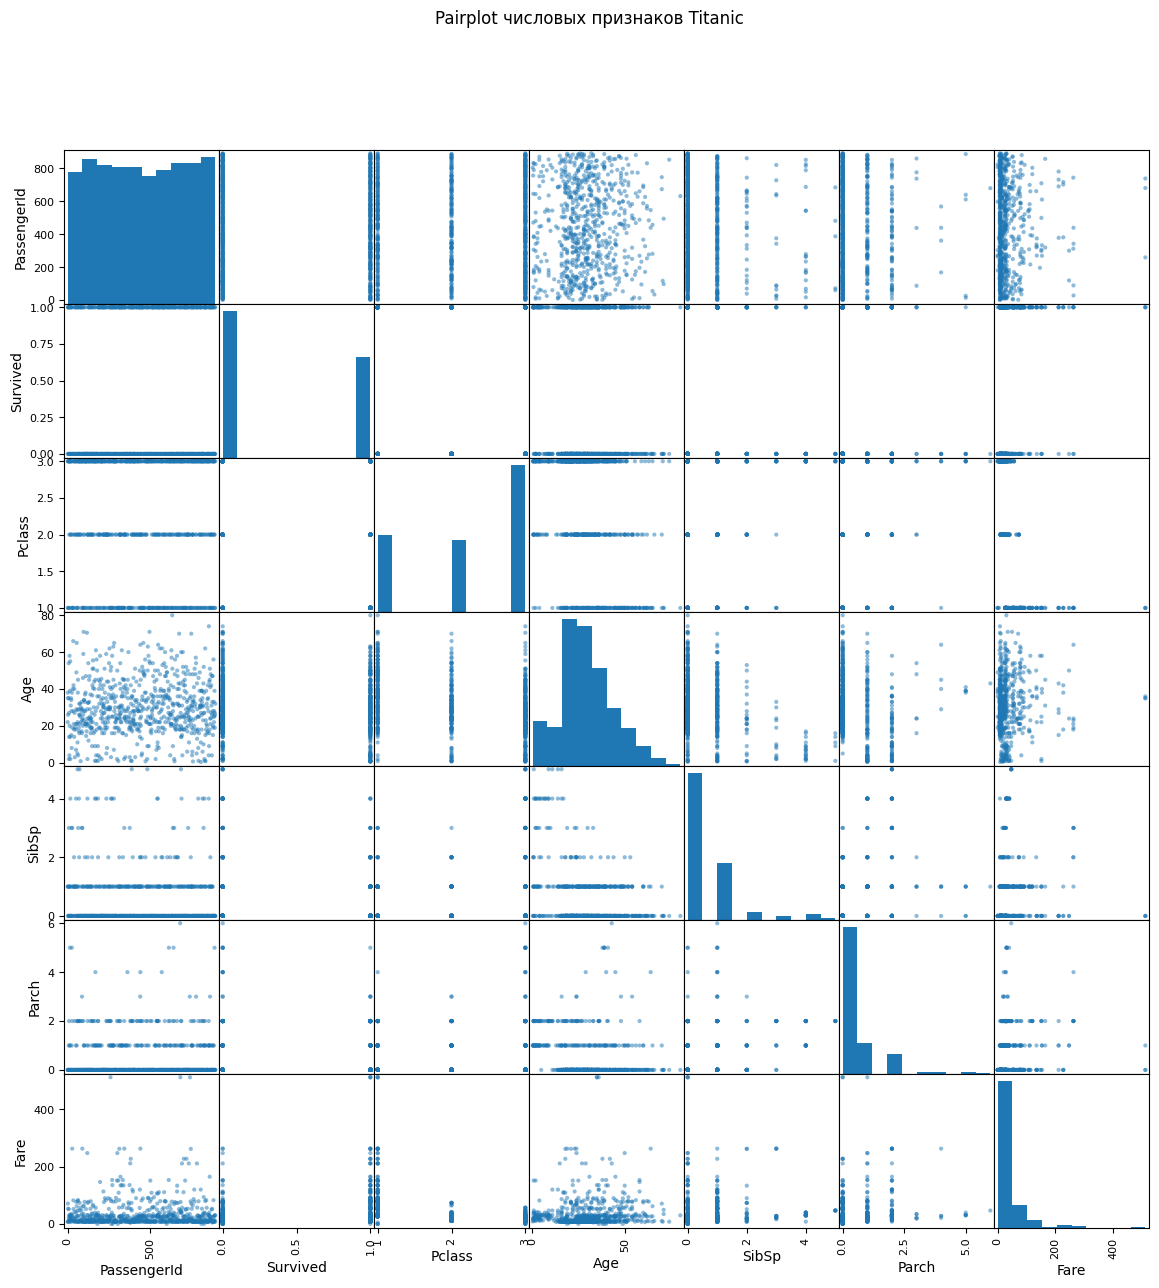

In [10]:
numeric_df = df.select_dtypes(include="number").dropna()

pd.plotting.scatter_matrix(
    numeric_df,
    figsize=(14, 14),
    diagonal="hist"
)

plt.suptitle("Pairplot числовых признаков Titanic")
plt.show()

# 7. Violin plot возраста в зависимости от пола

Violin plot показывает распределение возраста мужчин и женщин.

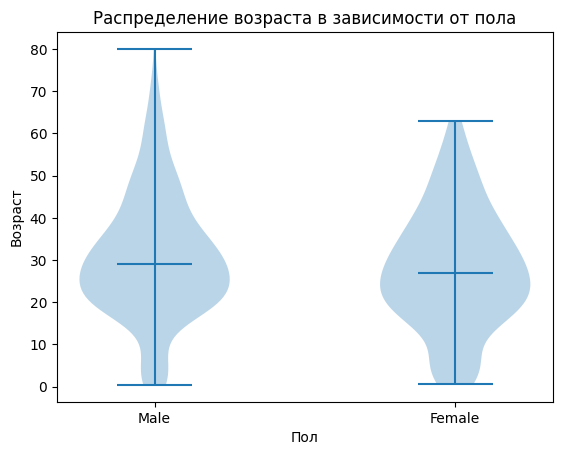

In [11]:
male_age = df[df["Sex"] == "male"]["Age"].dropna()
female_age = df[df["Sex"] == "female"]["Age"].dropna()

plt.violinplot([male_age, female_age], showmedians=True)
plt.xticks([1, 2], ["Male", "Female"])
plt.title("Распределение возраста в зависимости от пола")
plt.xlabel("Пол")
plt.ylabel("Возраст")
plt.show()

# 8. Heatmap корреляционной матрицы

Сначала рассчитаем корреляции между всеми числовыми признаками, затем отобразим их в виде тепловой карты.

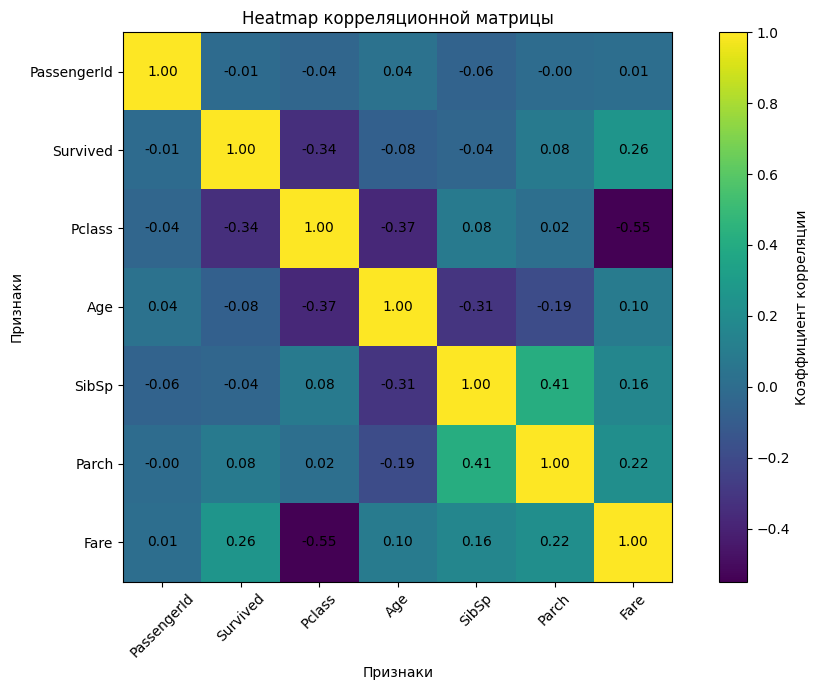

In [12]:
numeric_columns = df.select_dtypes(include="number")
correlation_matrix = numeric_columns.corr()

plt.figure(figsize=(10, 7))
plt.imshow(correlation_matrix)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.colorbar(label="Коэффициент корреляции")
plt.title("Heatmap корреляционной матрицы")
plt.xlabel("Признаки")
plt.ylabel("Признаки")

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        value = correlation_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

# 9. Интерактивный Sunburst plot

Первый уровень показывает класс пассажира, второй — пол пассажиров внутри каждого класса.

In [13]:
sunburst_data = df.groupby(["Pclass", "Sex"]).size().reset_index(name="Count")

sunburst_data["Pclass"] = sunburst_data["Pclass"].astype(str)

fig = px.sunburst(
    sunburst_data,
    path=["Pclass", "Sex"],
    values="Count",
    title="Количество пассажиров по классу и полу"
)

fig.show()

# Итог

В работе построены все требуемые типы визуализаций:

- распределения `Survived`, `Pclass`, `Age`, `Sex`, `Parch`;
- boxplot возраста и его интерпретация;
- pie chart для `Survived` и `Pclass`;
- pairplot-подобная матрица всех числовых признаков;
- violin plot возраста по полу;
- heatmap корреляционной матрицы;
- интерактивный sunburst plot.

Перед сдачей `hw_3.ipynb` и `train.csv` должны находиться в одной папке.